# Vector Matrix Multiplications

This notebook explores vector-matrix multiplications and the important operation $\mathbf{x}^T M \mathbf{x}$, which produces a scalar through quadratic forms.

## Introduction to Vector-Matrix Multiplications

**Definition and Setup**:

- Let $\mathbf{x}$ be a vector, i.e., $\mathbf{x} \in \mathbb{R}^d$

- Let $M$ be a square matrix, i.e., $M \in \mathbb{R}^{d \times d}$

**Three key operations in vector-matrix multiplications**:

1. **Matrix-Vector Product**: $M\mathbf{x}$ (produces a vector)
2. **Dot Product**: $\mathbf{x}^T \mathbf{y}$ (produces a scalar)
3. **Quadratic Form**: $\mathbf{x}^T M \mathbf{x}$ (produces a scalar)

## The Quadratic Form: $\mathbf{x}^T M \mathbf{x}$

### Definition

Consider the operation: $\mathbf{x}^T M \mathbf{x}$

When these 3 entities are multiplied together, the result will be a **scalar**.

### Mathematical Derivation

When $d=2$:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}, \quad M = \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix}$$

Step 1: Compute $M\mathbf{x}$:

$$M\mathbf{x} = \begin{bmatrix} m_{11} & m_{12} \\ m_{21} & m_{22} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} m_{11}x_1 + m_{12}x_2 \\ m_{21}x_1 + m_{22}x_2 \end{bmatrix}$$

Step 2: Compute $\mathbf{x}^T (M\mathbf{x})$:

$$\mathbf{x}^T M \mathbf{x} = \begin{bmatrix} x_1 & x_2 \end{bmatrix} \begin{bmatrix} m_{11}x_1 + m_{12}x_2 \\ m_{21}x_1 + m_{22}x_2 \end{bmatrix}$$

$$= x_1(m_{11}x_1 + m_{12}x_2) + x_2(m_{21}x_1 + m_{22}x_2)$$

### Expanded Form

$$\mathbf{x}^T M \mathbf{x} = m_{11}x_1^2 + m_{12}x_1 x_2 + m_{21}x_1 x_2 + m_{22}x_2^2$$

**Key Observation**: 
- The resulting expression is a **quadratic expression**
- It contains quadratic terms: $x_1^2$, $x_2^2$
- It contains cross terms: $x_1 x_2$
- Each term is **degree 2** (sum of exponents = 2)
- The term $\mathbf{x}^T M \mathbf{x}$ is called the **quadratic term**

### General Form for Dimension $d$

For an arbitrary dimension $d$:

$$\mathbf{x}^T M \mathbf{x} = \sum_{i=1}^{d} \sum_{j=1}^{d} m_{ij} x_i x_j$$

This can also be written as:

$$\mathbf{x}^T M \mathbf{x} = \sum_{i=1}^{d} m_{ii} x_i^2 + 2\sum_{i<j} m_{ij} x_i x_j$$

where:
- $m_{ii}$ are diagonal elements (coefficients of $x_i^2$)
- $m_{ij}$ with $i \neq j$ are off-diagonal elements (coefficients of $x_i x_j$)

## Types of Vector-Matrix Operations

### 1. Linear Form: $\mathbf{a}^T \mathbf{x}$

**Result**: Scalar

**Expression**: $\mathbf{a}^T \mathbf{x} = a_1 x_1 + a_2 x_2 + \cdots + a_d x_d$

**Degree**: 1 (linear in $\mathbf{x}$)

### 2. Bilinear Form: $\mathbf{x}^T M \mathbf{y}$

**Result**: Scalar

**Expression**: $\mathbf{x}^T M \mathbf{y} = \sum_{i=1}^{d} \sum_{j=1}^{d} m_{ij} x_i y_j$

**Degree**: 1 in $\mathbf{x}$ and 1 in $\mathbf{y}$ (bilinear)

### 3. Quadratic Form: $\mathbf{x}^T M \mathbf{x}$

**Result**: Scalar

**Expression**: $\mathbf{x}^T M \mathbf{x} = \sum_{i=1}^{d} \sum_{j=1}^{d} m_{ij} x_i x_j$

**Degree**: 2 (quadratic in $\mathbf{x}$)

**Special Case**: When $M$ is symmetric ($M = M^T$), the quadratic form simplifies:
$$\mathbf{x}^T M \mathbf{x} = \sum_{i=1}^{d} m_{ii} x_i^2 + 2\sum_{i<j} m_{ij} x_i x_j$$

## Applications of Quadratic Forms

**Machine Learning**:
- Loss functions in regression (Mean Squared Error)
- Kernel methods and kernel functions
- Covariance matrices and Mahalanobis distance

**Optimization**:
- Quadratic programming problems
- Hessian matrices in optimization
- Convexity analysis

**Physics and Engineering**:
- Kinetic energy (e.g., $E = \frac{1}{2}\mathbf{v}^T M \mathbf{v}$)
- Potential energy in springs
- Stress-strain relationships

**Statistics**:
- Chi-squared distributions
- Quadratic forms in hypothesis testing
- Variance analysis

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


print("="*70)
print("QUADRATIC FORM: x^T M x")
print("="*70)

# Example 1: 2D case
print("\n" + "="*70)
print("Example 1: 2D Quadratic Form")
print("="*70)

x = torch.tensor([2.0, 3.0])
M = torch.tensor([
    [2.0, 0.5],
    [0.5, 1.0]
])

print(f"\nVector x: {x.tolist()}")
print(f"Matrix M:")
print(M)

# Method 1: Direct computation using torch.matmul and dot product
quadratic_form = torch.matmul(x, torch.matmul(M, x))

print(f"\nQuadratic form x^T M x = {quadratic_form:.4f}")

# Method 2: Element-wise computation to show the quadratic expression
print(f"\n" + "-"*70)
print("Element-wise expansion:")
print("-"*70)

quad_term = M[0,0] * x[0]**2
print(f"Quadratic term (x-axis): m₁₁·x₁² = {M[0,0]:.1f}·({x[0]:.1f})² = {quad_term:.4f}")

cross_term = 2 * M[0,1] * x[0] * x[1]
print(f"Cross term: 2·m₁₂·x₁·x₂ = 2·{M[0,1]:.1f}·{x[0]:.1f}·{x[1]:.1f} = {cross_term:.4f}")

quad_term_y = M[1,1] * x[1]**2
print(f"Quadratic term (y-axis): m₂₂·x₂² = {M[1,1]:.1f}·({x[1]:.1f})² = {quad_term_y:.4f}")

total = quad_term + cross_term + quad_term_y
print(f"\nTotal: {quad_term:.4f} + {cross_term:.4f} + {quad_term_y:.4f} = {total:.4f}")
print(f"Direct computation: {quadratic_form:.4f}")
print(f"Match? {torch.isclose(quadratic_form, total)}")

QUADRATIC FORM: x^T M x

Example 1: 2D Quadratic Form

Vector x: [2.0, 3.0]
Matrix M:
tensor([[2.0000, 0.5000],
        [0.5000, 1.0000]])

Quadratic form x^T M x = 23.0000

----------------------------------------------------------------------
Element-wise expansion:
----------------------------------------------------------------------
Quadratic term (x-axis): m₁₁·x₁² = 2.0·(2.0)² = 8.0000
Cross term: 2·m₁₂·x₁·x₂ = 2·0.5·2.0·3.0 = 6.0000
Quadratic term (y-axis): m₂₂·x₂² = 1.0·(3.0)² = 9.0000

Total: 8.0000 + 6.0000 + 9.0000 = 23.0000
Direct computation: 23.0000
Match? True


In [ ]:
# Example 2: 3D case
print("\n" + "="*70)
print("Example 2: 3D Quadratic Form")
print("="*70)

x_3d = torch.tensor([1.0, 2.0, 1.5])
M_3d = torch.tensor([
    [3.0, 0.5, 0.2],
    [0.5, 2.0, 0.3],
    [0.2, 0.3, 1.0]
])

print(f"\nVector x: {x_3d.tolist()}")
print(f"Matrix M (3x3):")
print(M_3d)

quadratic_form_3d = torch.matmul(x_3d, torch.matmul(M_3d, x_3d))
print(f"\nQuadratic form x^T M x = {quadratic_form_3d:.4f}")

print(f"\nExpanded quadratic expression:")
print(f"x^T M x = m₁₁·x₁² + m₂₂·x₂² + m₃₃·x₃² + 2·m₁₂·x₁·x₂ + 2·m₁₃·x₁·x₃ + 2·m₂₃·x₂·x₃")

print(f"\n= {M_3d[0,0]:.1f}·({x_3d[0]:.1f})² + {M_3d[1,1]:.1f}·({x_3d[1]:.1f})² + {M_3d[2,2]:.1f}·({x_3d[2]:.1f})²")
print(f"  + 2·{M_3d[0,1]:.1f}·{x_3d[0]:.1f}·{x_3d[1]:.1f} + 2·{M_3d[0,2]:.1f}·{x_3d[0]:.1f}·{x_3d[2]:.1f} + 2·{M_3d[1,2]:.1f}·{x_3d[1]:.1f}·{x_3d[2]:.1f}")

term1 = M_3d[0,0] * x_3d[0]**2
term2 = M_3d[1,1] * x_3d[1]**2
term3 = M_3d[2,2] * x_3d[2]**2
term4 = 2 * M_3d[0,1] * x_3d[0] * x_3d[1]
term5 = 2 * M_3d[0,2] * x_3d[0] * x_3d[2]
term6 = 2 * M_3d[1,2] * x_3d[1] * x_3d[2]

print(f"\n= {term1:.4f} + {term2:.4f} + {term3:.4f} + {term4:.4f} + {term5:.4f} + {term6:.4f}")
print(f"= {term1 + term2 + term3 + term4 + term5 + term6:.4f}")


Example 2: 3D Quadratic Form

Vector x: [1.0, 2.0, 1.5]
Matrix M (3x3):
tensor([[3.0000, 0.5000, 0.2000],
        [0.5000, 2.0000, 0.3000],
        [0.2000, 0.3000, 1.0000]])

Quadratic form x^T M x = 17.6500

Expanded quadratic expression:
x^T M x = m₁₁·x₁² + m₂₂·x₂² + m₃₃·x₃² + 2·m₁₂·x₁·x₂ + 2·m₁₃·x₁·x₃ + 2·m₂₃·x₂·x₃

= 3.0·(1.0)² + 2.0·(2.0)² + 1.0·(1.5)²
  + 2·0.5·1.0·2.0 + 2·0.2·1.0·1.5 + 2·0.3·2.0·1.5

= 3.0000 + 8.0000 + 2.2500 + 2.0000 + 0.6000 + 1.8000
= 17.6500


In [ ]:
# Example 3: Symmetric vs Asymmetric matrices
print("\n" + "="*70)
print("Example 3: Effect of Symmetry")
print("="*70)

x_test = torch.tensor([2.0, 3.0])

# Symmetric matrix
M_sym = torch.tensor([
    [2.0, 1.0],
    [1.0, 3.0]
])

# Asymmetric matrix
M_asym = torch.tensor([
    [2.0, 0.5],
    [1.5, 3.0]
])

print(f"\nVector x: {x_test.tolist()}")
print(f"\nSymmetric matrix M_sym:")
print(M_sym)
quad_sym = torch.matmul(x_test, torch.matmul(M_sym, x_test))
print(f"x^T M_sym x = {quad_sym:.4f}")

print(f"\nAsymmetric matrix M_asym:")
print(M_asym)
quad_asym = torch.matmul(x_test, torch.matmul(M_asym, x_test))
print(f"x^T M_asym x = {quad_asym:.4f}")

print(f"\nNote: For symmetric matrices, m_ij = m_ji")
print(f"For quadratic forms, symmetric and asymmetric matrices can yield")
print(f"the same result due to the symmetry of the operation.")


Example 3: Effect of Symmetry

Vector x: [2.0, 3.0]

Symmetric matrix M_sym:
tensor([[2., 1.],
        [1., 3.]])
x^T M_sym x = 47.0000

Asymmetric matrix M_asym:
tensor([[2.0000, 0.5000],
        [1.5000, 3.0000]])
x^T M_asym x = 47.0000

Note: For symmetric matrices, m_ij = m_ji
For quadratic forms, symmetric and asymmetric matrices can yield
the same result due to the symmetry of the operation.



Example 4: Visualization of Quadratic Form

Matrix M:
[[1.  0.3]
 [0.3 0.5]]


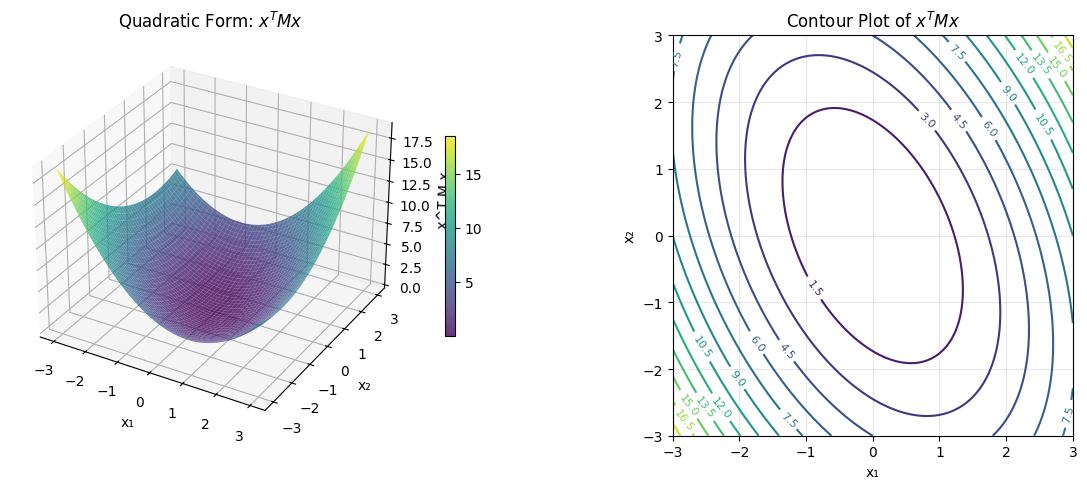

The surface represents all values of x^T M x for different input vectors (x₁, x₂)


In [ ]:
# Example 4: Visualization of Quadratic Form
print("\n" + "="*70)
print("Example 4: Visualization of Quadratic Form")
print("="*70)

# Create 2D grid of x values
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_range, y_range)

# Define a symmetric matrix
M_viz = np.array([
    [1.0, 0.3],
    [0.3, 0.5]
])

# Compute quadratic form for each point
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_point = np.array([X[i,j], Y[i,j]])
        Z[i,j] = x_point @ M_viz @ x_point

print(f"\nMatrix M:")
print(M_viz)

# Plot
fig = plt.figure(figsize=(14, 5))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('x^T M x')
ax1.set_title('Quadratic Form: $x^T M x$')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=15, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Contour Plot of $x^T M x$')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"The surface represents all values of x^T M x for different input vectors (x₁, x₂)")

In [ ]:
# Example 5: Comparison of different operations
print("\n" + "="*70)
print("Example 5: Types of Vector-Matrix Operations")
print("="*70)

x = torch.tensor([2.0, 3.0])
y = torch.tensor([1.0, 2.0])
a = torch.tensor([1.0, 0.5])
M = torch.tensor([
    [2.0, 0.5],
    [0.5, 1.0]
])

print(f"\nVector x: {x.tolist()}")
print(f"Vector y: {y.tolist()}")
print(f"Vector a: {a.tolist()}")
print(f"Matrix M:")
print(M)

# 1. Linear form
linear_form = torch.matmul(a, x)
print(f"\n1. LINEAR FORM: a^T x")
print(f"   Result: {linear_form:.4f}")
print(f"   Degree: 1 (linear)")

# 2. Bilinear form
bilinear_form = torch.matmul(x, torch.matmul(M, y))
print(f"\n2. BILINEAR FORM: x^T M y")
print(f"   Result: {bilinear_form:.4f}")
print(f"   Degree: 1 in x, 1 in y (bilinear)")

# 3. Quadratic form
quadratic_form = torch.matmul(x, torch.matmul(M, x))
print(f"\n3. QUADRATIC FORM: x^T M x")
print(f"   Result: {quadratic_form:.4f}")
print(f"   Degree: 2 (quadratic)")

print(f"\n" + "-"*70)
print(f"Summary:")
print(f"-"*70)
print(f"All three operations produce SCALARS")
print(f"But they differ in:")
print(f"  • Number of vectors involved")
print(f"  • Degree of the resulting polynomial")
print(f"  • Mathematical properties")


Example 5: Types of Vector-Matrix Operations

Vector x: [2.0, 3.0]
Vector y: [1.0, 2.0]
Vector a: [1.0, 0.5]
Matrix M:
tensor([[2.0000, 0.5000],
        [0.5000, 1.0000]])

1. LINEAR FORM: a^T x
   Result: 3.5000
   Degree: 1 (linear)

2. BILINEAR FORM: x^T M y
   Result: 13.5000
   Degree: 1 in x, 1 in y (bilinear)

3. QUADRATIC FORM: x^T M x
   Result: 23.0000
   Degree: 2 (quadratic)

----------------------------------------------------------------------
Summary:
----------------------------------------------------------------------
All three operations produce SCALARS
But they differ in:
  • Number of vectors involved
  • Degree of the resulting polynomial
  • Mathematical properties
